In [ ]:
!pip -q install torch torchaudio pandas librosa scikit-learn tqdm seaborn joblib

import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ZIP_PATH = '/content/drive/MyDrive/keystroke_clean.zip'
EXTRACT_DIR = '/content/dataset'

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Done!")

Extracting dataset...
Done!


In [ ]:
TRAIN_DIR = Path('/content/dataset/keystroke_clean/data_raw/Train/Train')
VALID_DIR = Path('/content/dataset/keystroke_clean/data_raw/Valid/Valid')
TEST_DIR  = Path('/content/dataset/keystroke_clean/data_raw/Test/Test')

print("TRAIN_DIR:", TRAIN_DIR.exists())
print("VALID_DIR:", VALID_DIR.exists())
print("TEST_DIR :", TEST_DIR.exists())

TRAIN_DIR: True
VALID_DIR: True
TEST_DIR : True


In [ ]:
train_df = pd.read_csv(TRAIN_DIR / 'labels.csv')
valid_df = pd.read_csv(VALID_DIR / 'labels.csv')
test_df  = pd.read_csv(TEST_DIR / 'labels.csv')

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

print(train_df.head())

Train: (5120, 5)
Valid: (1280, 5)
Test : (1600, 5)
    filename key original_path  duration_s segment_id
0   a_10.wav   a    a/a_10.wav        0.38       a_10
1  a_103.wav   a   a/a_103.wav        0.38      a_103
2  a_110.wav   a   a/a_110.wav        0.38      a_110
3  a_113.wav   a   a/a_113.wav        0.38      a_113
4  a_127.wav   a   a/a_127.wav        0.38      a_127


In [ ]:
def attach_filepaths(df, split_dir):
    df = df.copy()
    audio_dir = split_dir / 'audio_data'
    df['filepath'] = df['filename'].apply(lambda x: str(audio_dir / x))
    df['exists'] = df['filepath'].apply(os.path.exists)
    return df[df['exists']].reset_index(drop=True)

train_df = attach_filepaths(train_df, TRAIN_DIR)
valid_df = attach_filepaths(valid_df, VALID_DIR)
test_df  = attach_filepaths(test_df, TEST_DIR)

print("Train after path check:", train_df.shape)
print("Valid after path check:", valid_df.shape)
print("Test after path check :", test_df.shape)

Train after path check: (5120, 7)
Valid after path check: (1280, 7)
Test after path check : (1600, 7)


In [ ]:
classes = sorted(train_df['key'].unique())
label2id = {k: i for i, k in enumerate(classes)}
id2label = {i: k for k, i in label2id.items()}
num_classes = len(classes)

print("Classes:", classes)
print("Num classes:", num_classes)

Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 'space', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Num classes: 27


In [ ]:
SR = 22050
DURATION = 0.40
MAX_LEN = int(SR * DURATION)

N_MFCC = 20
MAX_FRAMES = 40

print("SR:", SR)
print("MAX_LEN:", MAX_LEN)
print("N_MFCC:", N_MFCC)
print("MAX_FRAMES:", MAX_FRAMES)

SR: 22050
MAX_LEN: 8820
N_MFCC: 20
MAX_FRAMES: 40


In [ ]:
def extract_mfcc_sequence(path):
    y, _ = librosa.load(path, sr=SR, mono=True)

    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)))
    else:
        y = y[:MAX_LEN]

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=SR,
        n_mfcc=N_MFCC
    )

    if mfcc.shape[1] < MAX_FRAMES:
        pad = MAX_FRAMES - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad)))
    else:
        mfcc = mfcc[:, :MAX_FRAMES]

    return mfcc.T.astype(np.float32)   # (frames, features)

In [ ]:
sample_path = train_df.loc[0, 'filepath']
sample_label = train_df.loc[0, 'key']

x_sample = extract_mfcc_sequence(sample_path)

print("Sample path:", sample_path)
print("Sample label:", sample_label)
print("Shape:", x_sample.shape)   # should be (40, 20)

Sample path: /content/dataset/keystroke_clean/data_raw/Train/Train/audio_data/a_10.wav
Sample label: a
Shape: (40, 20)


In [ ]:
class KeystrokeDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = extract_mfcc_sequence(row['filepath'])
        y = label2id[row['key']]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [ ]:
train_ds = KeystrokeDataset(train_df)
valid_ds = KeystrokeDataset(valid_df)
test_ds  = KeystrokeDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=20, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, 2H)
        out = out.mean(dim=1)          # temporal average pooling
        out = self.dropout(out)
        out = self.fc(out)
        return out

model = LSTMModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

LSTMModel(
  (lstm): LSTM(20, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=27, bias=True)
)


In [ ]:
def evaluate_model(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()

            pred = out.argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc, y_true, y_pred

In [ ]:
EPOCHS = 15
MODEL_PATH = '/content/drive/MyDrive/best_lstm_model_clean.pth'

best_valid_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    valid_loss, valid_acc, _, _ = evaluate_model(model, valid_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"✓ Best model saved: {MODEL_PATH}")

Epoch 1/15: 100%|██████████| 80/80 [01:06<00:00,  1.20it/s]


Epoch 1/15 | Train Loss: 2.8307 | Valid Loss: 1.9467 | Valid Acc: 0.3883
✓ Best model saved: /content/drive/MyDrive/best_lstm_model_clean.pth


Epoch 2/15: 100%|██████████| 80/80 [00:57<00:00,  1.40it/s]


Epoch 2/15 | Train Loss: 1.5207 | Valid Loss: 1.1382 | Valid Acc: 0.6266
✓ Best model saved: /content/drive/MyDrive/best_lstm_model_clean.pth


Epoch 3/15: 100%|██████████| 80/80 [00:54<00:00,  1.47it/s]


...

Epoch 13/15 | Train Loss: 0.2540 | Valid Loss: 0.2797 | Valid Acc: 0.9133
✓ Best model saved: /content/drive/MyDrive/best_lstm_model_clean.pth


Epoch 14/15: 100%|██████████| 80/80 [00:56<00:00,  1.41it/s]


Epoch 14/15 | Train Loss: 0.2199 | Valid Loss: 0.2484 | Valid Acc: 0.9234
✓ Best model saved: /content/drive/MyDrive/best_lstm_model_clean.pth


Epoch 15/15: 100%|██████████| 80/80 [00:54<00:00,  1.47it/s]


Epoch 15/15 | Train Loss: 0.2060 | Valid Loss: 0.2397 | Valid Acc: 0.9219


In [ ]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
print("Best model loaded.")
print("Best validation accuracy:", best_valid_acc)

Best model loaded.
Best validation accuracy: 0.9234375


In [ ]:
test_loss, test_acc, y_true, y_pred = evaluate_model(model, test_loader)

print(f"TEST LOSS: {test_loss:.4f}")
print(f"TEST ACCURACY: {test_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=classes))

TEST LOSS: 0.2840
TEST ACCURACY: 0.9181
              precision    recall  f1-score   support

           a       0.82      0.93      0.87        59
           b       0.81      0.95      0.88        59
           c       0.88      0.98      0.93        59
           d       0.93      0.97      0.95        59
           e       0.93      0.95      0.94        59
           f       0.84      0.86      0.85        59
           g       0.81      0.93      0.87        59
           h       1.00      0.93      0.96        59
           i       0.95      1.00      0.98        60
           j       0.89      0.81      0.85        59
           k       0.96      0.83      0.89        59
           l       0.95      0.97      0.96        59
           m       0.96      0.88      0.92        59
           n       0.93      0.97      0.95        59
           o       0.98      0.90      0.94        59
           p       0.98      0.92      0.95        59
           q       0.94      1.00      0.

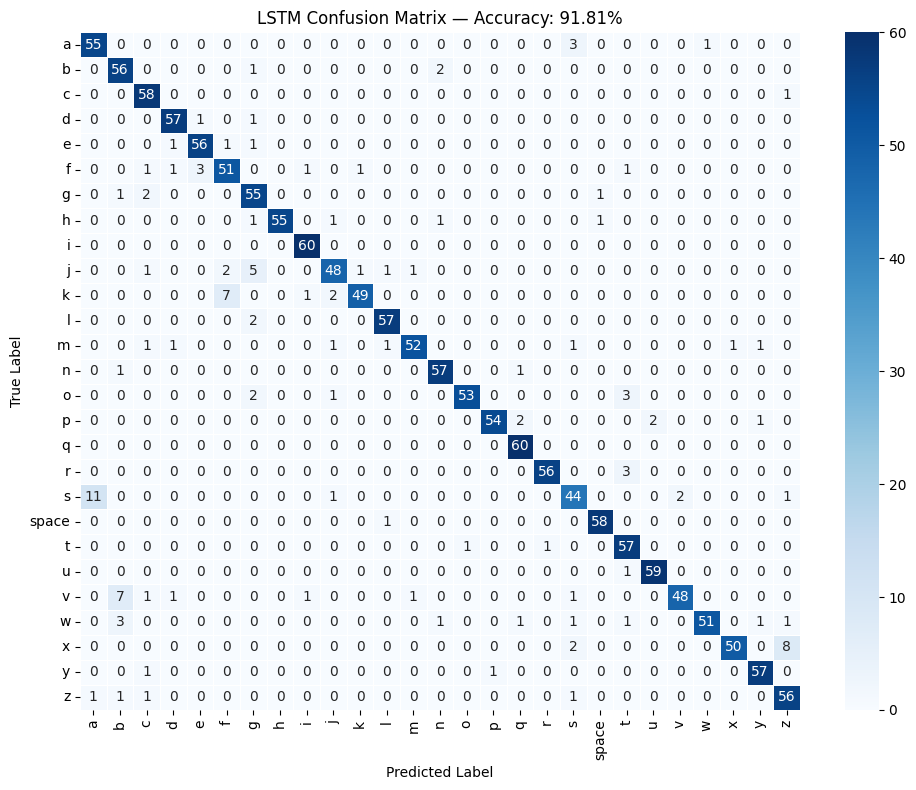

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    linewidths=0.5
)
plt.title(f'LSTM Confusion Matrix — Accuracy: {test_acc*100:.2f}%')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
summary_df = pd.DataFrame([{
    'Model': 'LSTM',
    'Test Loss': test_loss,
    'Test Accuracy': test_acc,
    'Num Classes': num_classes,
    'MFCC Features': N_MFCC,
    'Max Frames': MAX_FRAMES,
    'Epochs': EPOCHS
}])

summary_path = '/content/drive/MyDrive/lstm_test_summary_clean.csv'
summary_df.to_csv(summary_path, index=False)

print("Saved summary to:", summary_path)

Saved summary to: /content/drive/MyDrive/lstm_test_summary_clean.csv


In [ ]:
cm_path = '/content/drive/MyDrive/lstm_confusion_clean.csv'
pd.DataFrame(cm, index=classes, columns=classes).to_csv(cm_path)

print("Saved confusion matrix to:", cm_path)
print("Saved model to:", MODEL_PATH)

Saved confusion matrix to: /content/drive/MyDrive/lstm_confusion_clean.csv
Saved model to: /content/drive/MyDrive/best_lstm_model_clean.pth


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

def evaluate_clean(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            pred = out.argmax(dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    return acc, prec, f1, y_true, y_pred

clean_acc, clean_prec, clean_f1, clean_y_true, clean_y_pred = evaluate_clean(model, test_loader)

print("===== CLEAN RESULTS =====")
print(f"Accuracy  : {clean_acc:.4f}")
print(f"Precision : {clean_prec:.4f}")
print(f"F1-score  : {clean_f1:.4f}")
print(classification_report(clean_y_true, clean_y_pred, target_names=classes, zero_division=0))

===== CLEAN RESULTS =====
Accuracy  : 0.9181
Precision : 0.9220
F1-score  : 0.9179
              precision    recall  f1-score   support

           a       0.82      0.93      0.87        59
           b       0.81      0.95      0.88        59
           c       0.88      0.98      0.93        59
           d       0.93      0.97      0.95        59
           e       0.93      0.95      0.94        59
           f       0.84      0.86      0.85        59
           g       0.81      0.93      0.87        59
           h       1.00      0.93      0.96        59
           i       0.95      1.00      0.98        60
           j       0.89      0.81      0.85        59
           k       0.96      0.83      0.89        59
           l       0.95      0.97      0.96        59
           m       0.96      0.88      0.92        59
           n       0.93      0.97      0.95        59
           o       0.98      0.90      0.94        59
           p       0.98      0.92      0.95        5

In [ ]:
print("Computing feature bounds from test set...")

all_features = []

for xb, _ in test_loader:
    all_features.append(xb)

all_features = torch.cat(all_features, dim=0)
feat_min = all_features.min().item()
feat_max = all_features.max().item()

print(f"Feature bounds: [{feat_min:.4f}, {feat_max:.4f}]")

Computing feature bounds from test set...
Feature bounds: [-1021.6101, 175.5742]


In [ ]:
def fgsm_attack(model, x, y, epsilon):
    x_adv = x.clone().detach().to(device)
    y = y.to(device)

    x_adv.requires_grad_(True)

    with torch.enable_grad():
        out = model(x_adv)
        loss = criterion(out, y)
        model.zero_grad()
        loss.backward()

    grad_sign = x_adv.grad.detach().sign()
    x_adv = x_adv.detach() + epsilon * grad_sign
    x_adv = torch.clamp(x_adv, feat_min, feat_max)

    return x_adv.detach()


def bim_attack(model, x, y, epsilon, alpha, steps):
    x_orig = x.clone().detach().to(device)
    y = y.to(device)
    x_adv = x_orig.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        with torch.enable_grad():
            out = model(x_adv)
            loss = criterion(out, y)
            model.zero_grad()
            loss.backward()

        grad_sign = x_adv.grad.detach().sign()
        x_adv = x_adv.detach() + alpha * grad_sign

        delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
        x_adv = torch.clamp(x_orig + delta, feat_min, feat_max).detach()

    return x_adv


def pgd_attack(model, x, y, epsilon, alpha, steps):
    x_orig = x.clone().detach().to(device)
    y = y.to(device)

    x_adv = x_orig + torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
    delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
    x_adv = torch.clamp(x_orig + delta, feat_min, feat_max).detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        with torch.enable_grad():
            out = model(x_adv)
            loss = criterion(out, y)
            model.zero_grad()
            loss.backward()

        grad_sign = x_adv.grad.detach().sign()
        x_adv = x_adv.detach() + alpha * grad_sign

        delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
        x_adv = torch.clamp(x_orig + delta, feat_min, feat_max).detach()

    return x_adv

In [ ]:
def evaluate_attack(model, loader, attack_fn, attack_name, epsilon, **kwargs):
    model.eval()
    y_true, y_pred = [], []

    for x, y in tqdm(loader, desc=f"{attack_name} eps={epsilon}"):
        x_adv = attack_fn(model, x, y, epsilon, **kwargs)

        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    asr = 1.0 - acc

    print(f"\n===== {attack_name} | epsilon={epsilon} =====")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Precision          : {prec:.4f}")
    print(f"F1-score           : {f1:.4f}")
    print(f"Attack Success Rate: {asr:.4f}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

    return {
        "attack": attack_name,
        "epsilon": epsilon,
        "accuracy": acc,
        "precision": prec,
        "f1_score": f1,
        "asr": asr,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [ ]:
EPSILONS = [0.005, 0.01, 0.02, 0.05]
ALPHA_RATIO = 0.25
STEPS = 20

print("Attack setup ready.")
print("EPSILONS:", EPSILONS)
print("ALPHA_RATIO:", ALPHA_RATIO)
print("STEPS:", STEPS)

Attack setup ready.
EPSILONS: [0.005, 0.01, 0.02, 0.05]
ALPHA_RATIO: 0.25
STEPS: 20


In [ ]:
def fgsm_attack(model, x, y, epsilon):
    model.train()   # needed for cudnn LSTM backward

    x_adv = x.clone().detach().to(device)
    y = y.to(device)

    x_adv.requires_grad_(True)

    out = model(x_adv)
    loss = criterion(out, y)
    model.zero_grad()
    loss.backward()

    grad_sign = x_adv.grad.detach().sign()
    x_adv = x_adv.detach() + epsilon * grad_sign
    x_adv = torch.clamp(x_adv, feat_min, feat_max)

    model.eval()
    return x_adv.detach()


def bim_attack(model, x, y, epsilon, alpha, steps):
    model.train()   # needed for cudnn LSTM backward

    x_orig = x.clone().detach().to(device)
    y = y.to(device)
    x_adv = x_orig.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        out = model(x_adv)
        loss = criterion(out, y)
        model.zero_grad()
        loss.backward()

        grad_sign = x_adv.grad.detach().sign()
        x_adv = x_adv.detach() + alpha * grad_sign

        delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
        x_adv = torch.clamp(x_orig + delta, feat_min, feat_max).detach()

    model.eval()
    return x_adv


def pgd_attack(model, x, y, epsilon, alpha, steps):
    model.train()   # needed for cudnn LSTM backward

    x_orig = x.clone().detach().to(device)
    y = y.to(device)

    x_adv = x_orig + torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
    delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
    x_adv = torch.clamp(x_orig + delta, feat_min, feat_max).detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        out = model(x_adv)
        loss = criterion(out, y)
        model.zero_grad()
        loss.backward()

        grad_sign = x_adv.grad.detach().sign()
        x_adv = x_adv.detach() + alpha * grad_sign

        delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
        x_adv = torch.clamp(x_orig + delta, feat_min, feat_max).detach()

    model.eval()
    return x_adv

In [ ]:
all_results = []

for eps in EPSILONS:
    alpha = eps * ALPHA_RATIO

    try:
        r1 = evaluate_attack(model, test_loader, fgsm_attack, "FGSM", eps)
        all_results.append(r1)

        r2 = evaluate_attack(model, test_loader, bim_attack, "BIM", eps, alpha=alpha, steps=STEPS)
        all_results.append(r2)

        r3 = evaluate_attack(model, test_loader, pgd_attack, "PGD", eps, alpha=alpha, steps=STEPS)
        all_results.append(r3)

    except Exception as e:
        print(f"ERROR at epsilon {eps}:", e)

FGSM eps=0.005: 100%|██████████| 13/13 [00:18<00:00,  1.44s/it]



===== FGSM | epsilon=0.005 =====
Accuracy           : 0.9163
Precision          : 0.9205
F1-score           : 0.9161
Attack Success Rate: 0.0837
              precision    recall  f1-score   support

           a       0.82      0.93      0.87        59
           b       0.80      0.95      0.87        59
           c       0.88      0.98      0.93        59
           d       0.93      0.97      0.95        59
           e       0.93      0.93      0.93        59
           f       0.82      0.86      0.84        59
           g       0.81      0.93      0.87        59
           h       1.00      0.93      0.96        59
           i       0.95      1.00      0.98        60
           j       0.89      0.81      0.85        59
           k       0.96      0.81      0.88        59
           l       0.95      0.97      0.96        59
           m       0.96      0.88      0.92        59
           n       0.93      0.97      0.95        59
           o       0.98      0.90      0.94

BIM eps=0.005: 100%|██████████| 13/13 [00:24<00:00,  1.87s/it]



===== BIM | epsilon=0.005 =====
Accuracy           : 0.9163
Precision          : 0.9205
F1-score           : 0.9161
Attack Success Rate: 0.0837
              precision    recall  f1-score   support

           a       0.82      0.93      0.87        59
           b       0.80      0.95      0.87        59
           c       0.88      0.98      0.93        59
           d       0.93      0.97      0.95        59
           e       0.93      0.93      0.93        59
           f       0.82      0.86      0.84        59
           g       0.81      0.93      0.87        59
           h       1.00      0.93      0.96        59
           i       0.95      1.00      0.98        60
           j       0.89      0.81      0.85        59
           k       0.96      0.81      0.88        59
           l       0.95      0.97      0.96        59
           m       0.96      0.88      0.92        59
           n       0.93      0.97      0.95        59
           o       0.98      0.90      0.94 

PGD eps=0.005: 100%|██████████| 13/13 [00:17<00:00,  1.33s/it]


...


===== FGSM | epsilon=0.05 =====
Accuracy           : 0.9062
Precision          : 0.9116
F1-score           : 0.9061
Attack Success Rate: 0.0938
              precision    recall  f1-score   support

           a       0.83      0.92      0.87        59
           b       0.79      0.95      0.86        59
           c       0.85      0.98      0.91        59
           d       0.93      0.97      0.95        59
           e       0.93      0.90      0.91        59
           f       0.80      0.86      0.83        59
           g       0.77      0.93      0.85        59
           h       1.00      0.90      0.95        59
           i       0.94      1.00      0.97        60
           j       0.85      0.78      0.81        59
           k       0.96      0.78      0.86        59
           l       0.95      0.97      0.96        59
           m       0.96      0.86      0.91        59
           n       0.92      0.93      0.92        59
           o       0.98      0.90      0.94 

BIM eps=0.05: 100%|██████████| 13/13 [00:17<00:00,  1.35s/it]



===== BIM | epsilon=0.05 =====
Accuracy           : 0.9038
Precision          : 0.9092
F1-score           : 0.9037
Attack Success Rate: 0.0962
              precision    recall  f1-score   support

           a       0.82      0.92      0.86        59
           b       0.79      0.95      0.86        59
           c       0.83      0.98      0.90        59
           d       0.93      0.95      0.94        59
           e       0.93      0.90      0.91        59
           f       0.80      0.86      0.83        59
           g       0.77      0.93      0.85        59
           h       1.00      0.88      0.94        59
           i       0.94      1.00      0.97        60
           j       0.85      0.78      0.81        59
           k       0.96      0.78      0.86        59
           l       0.95      0.97      0.96        59
           m       0.96      0.86      0.91        59
           n       0.92      0.93      0.92        59
           o       0.98      0.90      0.94  

PGD eps=0.05: 100%|██████████| 13/13 [00:18<00:00,  1.40s/it]


===== PGD | epsilon=0.05 =====
Accuracy           : 0.9038
Precision          : 0.9092
F1-score           : 0.9037
Attack Success Rate: 0.0962
              precision    recall  f1-score   support

           a       0.82      0.92      0.86        59
           b       0.79      0.95      0.86        59
           c       0.83      0.98      0.90        59
           d       0.93      0.95      0.94        59
           e       0.93      0.90      0.91        59
           f       0.80      0.86      0.83        59
           g       0.77      0.93      0.85        59
           h       1.00      0.88      0.94        59
           i       0.94      1.00      0.97        60
           j       0.85      0.78      0.81        59
           k       0.96      0.78      0.86        59
           l       0.95      0.97      0.96        59
           m       0.96      0.86      0.91        59
           n       0.92      0.93      0.92        59
           o       0.98      0.90      0.94  

In [ ]:
rows = [{
    "Attack": "Clean",
    "Epsilon": "-",
    "Accuracy": round(clean_acc, 4),
    "Precision": round(clean_prec, 4),
    "F1-score": round(clean_f1, 4),
    "ASR": round(1 - clean_acc, 4)
}]

for r in all_results:
    rows.append({
        "Attack": r["attack"],
        "Epsilon": r["epsilon"],
        "Accuracy": round(r["accuracy"], 4),
        "Precision": round(r["precision"], 4),
        "F1-score": round(r["f1_score"], 4),
        "ASR": round(r["asr"], 4)
    })

attack_summary_df = pd.DataFrame(rows)
print(attack_summary_df.to_string(index=False))

Attack Epsilon  Accuracy  Precision  F1-score    ASR
 Clean       -    0.9181     0.9220    0.9179 0.0819
  FGSM   0.005    0.9163     0.9205    0.9161 0.0837
   BIM   0.005    0.9163     0.9205    0.9161 0.0837
   PGD   0.005    0.9163     0.9205    0.9161 0.0837
  FGSM    0.01    0.9150     0.9193    0.9148 0.0850
   BIM    0.01    0.9150     0.9193    0.9148 0.0850
   PGD    0.01    0.9150     0.9193    0.9148 0.0850
  FGSM    0.02    0.9131     0.9177    0.9130 0.0869
   BIM    0.02    0.9131     0.9177    0.9130 0.0869
   PGD    0.02    0.9137     0.9182    0.9135 0.0863
  FGSM    0.05    0.9062     0.9116    0.9061 0.0938
   BIM    0.05    0.9038     0.9092    0.9037 0.0962
   PGD    0.05    0.9038     0.9092    0.9037 0.0962


In [ ]:
attack_summary_path = "/content/drive/MyDrive/lstm_attack_summary_fgsm_bim_pgd.csv"
attack_summary_df.to_csv(attack_summary_path, index=False)
print("Saved summary to:", attack_summary_path)

Saved summary to: /content/drive/MyDrive/lstm_attack_summary_fgsm_bim_pgd.csv


In [ ]:
clean_cm = confusion_matrix(clean_y_true, clean_y_pred)
pd.DataFrame(clean_cm, index=classes, columns=classes).to_csv(
    "/content/drive/MyDrive/lstm_clean_confusion.csv"
)

for r in all_results:
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    fname = f"/content/drive/MyDrive/lstm_{r['attack'].lower()}_eps_{str(r['epsilon']).replace('.', '_')}_confusion.csv"
    pd.DataFrame(cm, index=classes, columns=classes).to_csv(fname)

print("Saved all confusion matrices to Google Drive.")

Saved all confusion matrices to Google Drive.


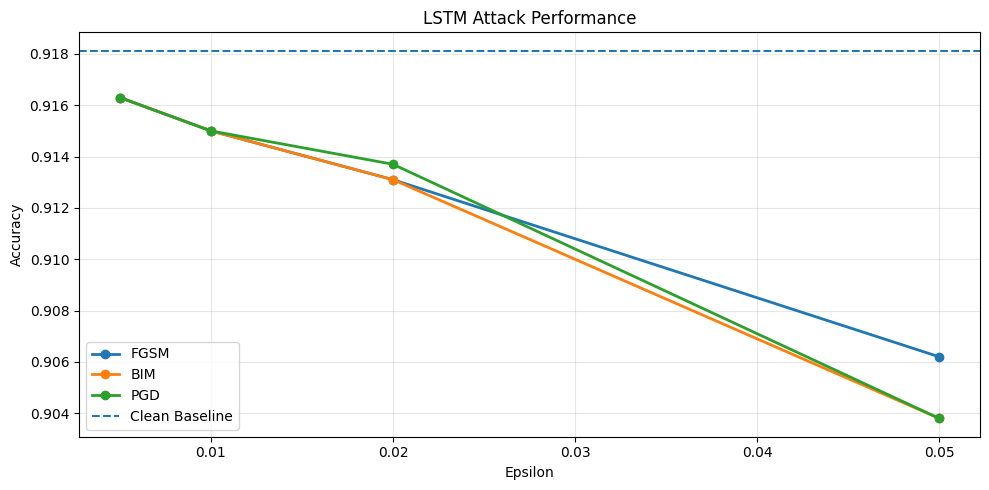

In [ ]:
plt.figure(figsize=(10, 5))

for attack_name in ["FGSM", "BIM", "PGD"]:
    sub = attack_summary_df[attack_summary_df["Attack"] == attack_name]
    if len(sub) > 0:
        plt.plot(sub["Epsilon"], sub["Accuracy"], marker='o', linewidth=2, label=attack_name)

plt.axhline(clean_acc, linestyle='--', linewidth=1.5, label='Clean Baseline')
plt.title("LSTM Attack Performance")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_attack = min(all_results, key=lambda x: x["accuracy"])

print("===== WORST-CASE ATTACK =====")
print("Attack   :", best_attack["attack"])
print("Epsilon  :", best_attack["epsilon"])
print("Accuracy :", round(best_attack["accuracy"], 4))
print("ASR      :", round(best_attack["asr"], 4))
print(classification_report(
    best_attack["y_true"],
    best_attack["y_pred"],
    target_names=classes,
    zero_division=0
))

===== WORST-CASE ATTACK =====
Attack   : BIM
Epsilon  : 0.05
Accuracy : 0.9038
ASR      : 0.0962
              precision    recall  f1-score   support

           a       0.82      0.92      0.86        59
           b       0.79      0.95      0.86        59
           c       0.83      0.98      0.90        59
           d       0.93      0.95      0.94        59
           e       0.93      0.90      0.91        59
           f       0.80      0.86      0.83        59
           g       0.77      0.93      0.85        59
           h       1.00      0.88      0.94        59
           i       0.94      1.00      0.97        60
           j       0.85      0.78      0.81        59
           k       0.96      0.78      0.86        59
           l       0.95      0.97      0.96        59
           m       0.96      0.86      0.91        59
           n       0.92      0.93      0.92        59
           o       0.98      0.90      0.94        59
           p       0.98      0.90     

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

def dft_perturb(x, epsilon):
    """
    x: torch tensor of shape (B, T, F)
    Applies FFT over time axis T, perturbs frequency-domain coefficients,
    then transforms back.
    """
    x_np = x.detach().cpu().numpy()                  # (B, T, F)
    Xf = np.fft.rfft(x_np, axis=1)

    noise = (np.random.randn(*Xf.shape) + 1j * np.random.randn(*Xf.shape)) * epsilon
    Xf_adv = Xf + noise

    x_ifft = np.fft.irfft(Xf_adv, n=x_np.shape[1], axis=1).astype(np.float32)

    delta = np.clip(x_ifft - x_np, -epsilon, epsilon)
    x_adv = x_np + delta

    return torch.tensor(x_adv, dtype=torch.float32, device=device)

In [ ]:
def dft_fgsm(model, x, y, epsilon):
    model.train()

    x = x.to(device)
    y = y.to(device)

    x_dft = dft_perturb(x, epsilon).detach()
    x_dft.requires_grad_(True)

    out = model(x_dft)
    loss = criterion(out, y)
    model.zero_grad()
    loss.backward()

    x_adv = x_dft + epsilon * x_dft.grad.detach().sign()
    model.eval()
    return x_adv.detach()


def dft_bim(model, x, y, epsilon, alpha, steps):
    model.train()

    x_orig = x.to(device).detach()
    y = y.to(device)

    x_adv = dft_perturb(x_orig, epsilon).detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        out = model(x_adv)
        loss = criterion(out, y)
        model.zero_grad()
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.detach().sign()
        x_adv = dft_perturb(x_adv.detach(), epsilon).detach()

        delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
        x_adv = (x_orig + delta).detach()

    model.eval()
    return x_adv


def dft_pgd(model, x, y, epsilon, alpha, steps):
    model.train()

    x_orig = x.to(device).detach()
    y = y.to(device)

    x_adv = dft_perturb(x_orig, epsilon).detach()
    delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
    x_adv = (x_orig + delta).detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        out = model(x_adv)
        loss = criterion(out, y)
        model.zero_grad()
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.detach().sign()
        x_adv = dft_perturb(x_adv.detach(), epsilon).detach()

        delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
        x_adv = (x_orig + delta).detach()

    model.eval()
    return x_adv

In [ ]:
def evaluate_clean(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Clean evaluation"):
            x = x.to(device)
            y = y.to(device)

            pred = model(x).argmax(dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    return acc, prec, f1, y_true, y_pred

clean_acc, clean_prec, clean_f1, clean_y_true, clean_y_pred = evaluate_clean(model, test_loader)

print("===== CLEAN RESULTS =====")
print(f"Accuracy  : {clean_acc:.4f}")
print(f"Precision : {clean_prec:.4f}")
print(f"F1-score  : {clean_f1:.4f}")
print(classification_report(clean_y_true, clean_y_pred, target_names=classes, zero_division=0))

Clean evaluation: 100%|██████████| 13/13 [00:21<00:00,  1.68s/it]

===== CLEAN RESULTS =====
Accuracy  : 0.9181
Precision : 0.9220
F1-score  : 0.9179
              precision    recall  f1-score   support

           a       0.82      0.93      0.87        59
           b       0.81      0.95      0.88        59
           c       0.88      0.98      0.93        59
           d       0.93      0.97      0.95        59
           e       0.93      0.95      0.94        59
           f       0.84      0.86      0.85        59
           g       0.81      0.93      0.87        59
           h       1.00      0.93      0.96        59
           i       0.95      1.00      0.98        60
           j       0.89      0.81      0.85        59
           k       0.96      0.83      0.89        59
           l       0.95      0.97      0.96        59
           m       0.96      0.88      0.92        59
           n       0.93      0.97      0.95        59
           o       0.98      0.90      0.94        59
           p       0.98      0.92      0.95        5

In [ ]:
def evaluate_attack(model, loader, attack_fn, attack_name, **kwargs):
    y_true, y_pred = [], []

    for x, y in tqdm(loader, desc=f"{attack_name} evaluation"):
        x_adv = attack_fn(model, x, y, **kwargs)

        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    asr = 1.0 - acc

    print(f"\n===== {attack_name} RESULTS =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ASR      : {asr:.4f}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

    return {
        "attack": attack_name,
        "accuracy": acc,
        "precision": prec,
        "f1_score": f1,
        "asr": asr,
        "y_true": y_true,
        "y_pred": y_pred
    }

In [ ]:
EPSILON = 0.03
ALPHA = 0.005
STEPS = 10

print("EPSILON:", EPSILON)
print("ALPHA  :", ALPHA)
print("STEPS  :", STEPS)

EPSILON: 0.03
ALPHA  : 0.005
STEPS  : 10


In [ ]:
dft_fgsm_results = evaluate_attack(
    model, test_loader, dft_fgsm, "DFT-FGSM", epsilon=EPSILON
)

dft_bim_results = evaluate_attack(
    model, test_loader, dft_bim, "DFT-BIM", epsilon=EPSILON, alpha=ALPHA, steps=STEPS
)

dft_pgd_results = evaluate_attack(
    model, test_loader, dft_pgd, "DFT-PGD", epsilon=EPSILON, alpha=ALPHA, steps=STEPS
)

DFT-FGSM evaluation: 100%|██████████| 13/13 [00:17<00:00,  1.36s/it]



===== DFT-FGSM RESULTS =====
Accuracy : 0.9094
Precision: 0.9142
F1-score : 0.9092
ASR      : 0.0906
              precision    recall  f1-score   support

           a       0.82      0.93      0.87        59
           b       0.79      0.95      0.86        59
           c       0.87      0.98      0.92        59
           d       0.93      0.97      0.95        59
           e       0.93      0.90      0.91        59
           f       0.80      0.86      0.83        59
           g       0.80      0.93      0.86        59
           h       1.00      0.93      0.96        59
           i       0.94      1.00      0.97        60
           j       0.87      0.78      0.82        59
           k       0.96      0.80      0.87        59
           l       0.95      0.97      0.96        59
           m       0.96      0.86      0.91        59
           n       0.92      0.95      0.93        59
           o       0.98      0.90      0.94        59
           p       0.98      0.90

DFT-BIM evaluation: 100%|██████████| 13/13 [00:18<00:00,  1.41s/it]



===== DFT-BIM RESULTS =====
Accuracy : 0.9106
Precision: 0.9154
F1-score : 0.9104
ASR      : 0.0894
              precision    recall  f1-score   support

           a       0.82      0.93      0.87        59
           b       0.79      0.95      0.86        59
           c       0.88      0.98      0.93        59
           d       0.93      0.97      0.95        59
           e       0.93      0.90      0.91        59
           f       0.80      0.86      0.83        59
           g       0.80      0.93      0.86        59
           h       1.00      0.93      0.96        59
           i       0.94      1.00      0.97        60
           j       0.87      0.78      0.82        59
           k       0.96      0.80      0.87        59
           l       0.95      0.97      0.96        59
           m       0.96      0.86      0.91        59
           n       0.93      0.95      0.94        59
           o       0.98      0.90      0.94        59
           p       0.98      0.90 

DFT-PGD evaluation: 100%|██████████| 13/13 [00:18<00:00,  1.43s/it]


===== DFT-PGD RESULTS =====
Accuracy : 0.9113
Precision: 0.9159
F1-score : 0.9111
ASR      : 0.0887
              precision    recall  f1-score   support

           a       0.83      0.93      0.88        59
           b       0.79      0.95      0.86        59
           c       0.88      0.98      0.93        59
           d       0.93      0.97      0.95        59
           e       0.93      0.92      0.92        59
           f       0.80      0.86      0.83        59
           g       0.80      0.93      0.86        59
           h       1.00      0.93      0.96        59
           i       0.94      1.00      0.97        60
           j       0.87      0.78      0.82        59
           k       0.96      0.80      0.87        59
           l       0.95      0.97      0.96        59
           m       0.96      0.86      0.91        59
           n       0.93      0.95      0.94        59
           o       0.98      0.90      0.94        59
           p       0.98      0.90 

In [ ]:
summary_df = pd.DataFrame([
    {
        "Attack": "Clean",
        "Accuracy": clean_acc,
        "Precision": clean_prec,
        "F1-score": clean_f1,
        "ASR": 1.0 - clean_acc
    },
    {
        "Attack": "DFT-FGSM",
        "Accuracy": dft_fgsm_results["accuracy"],
        "Precision": dft_fgsm_results["precision"],
        "F1-score": dft_fgsm_results["f1_score"],
        "ASR": dft_fgsm_results["asr"]
    },
    {
        "Attack": "DFT-BIM",
        "Accuracy": dft_bim_results["accuracy"],
        "Precision": dft_bim_results["precision"],
        "F1-score": dft_bim_results["f1_score"],
        "ASR": dft_bim_results["asr"]
    },
    {
        "Attack": "DFT-PGD",
        "Accuracy": dft_pgd_results["accuracy"],
        "Precision": dft_pgd_results["precision"],
        "F1-score": dft_pgd_results["f1_score"],
        "ASR": dft_pgd_results["asr"]
    }
])

print(summary_df.to_string(index=False))

  Attack  Accuracy  Precision  F1-score      ASR
   Clean  0.918125   0.922001  0.917936 0.081875
DFT-FGSM  0.909375   0.914235  0.909153 0.090625
 DFT-BIM  0.910625   0.915355  0.910434 0.089375
 DFT-PGD  0.911250   0.915916  0.911082 0.088750


In [ ]:
summary_path = "/content/drive/MyDrive/lstm_dft_attack_summary.csv"
summary_df.to_csv(summary_path, index=False)

pd.DataFrame(
    confusion_matrix(clean_y_true, clean_y_pred),
    index=classes, columns=classes
).to_csv("/content/drive/MyDrive/lstm_dft_clean_confusion.csv")

pd.DataFrame(
    confusion_matrix(dft_fgsm_results["y_true"], dft_fgsm_results["y_pred"]),
    index=classes, columns=classes
).to_csv("/content/drive/MyDrive/lstm_dft_fgsm_confusion.csv")

pd.DataFrame(
    confusion_matrix(dft_bim_results["y_true"], dft_bim_results["y_pred"]),
    index=classes, columns=classes
).to_csv("/content/drive/MyDrive/lstm_dft_bim_confusion.csv")

pd.DataFrame(
    confusion_matrix(dft_pgd_results["y_true"], dft_pgd_results["y_pred"]),
    index=classes, columns=classes
).to_csv("/content/drive/MyDrive/lstm_dft_pgd_confusion.csv")

print("Saved summary to:", summary_path)
print("Saved all confusion matrices to Google Drive.")

Saved summary to: /content/drive/MyDrive/lstm_dft_attack_summary.csv
Saved all confusion matrices to Google Drive.


In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------
# EXPECTED AVAILABLE VARIABLES
# -------------------------------------------------
# clean_acc                     -> clean LSTM accuracy (float)
# attack_summary_df             -> FGSM/BIM/PGD summary dataframe
# summary_df                    -> DFT summary dataframe
#
# attack_summary_df columns expected:
#   Attack, Epsilon, Accuracy, Precision, F1-score, ASR
#
# summary_df columns expected (DFT):
#   Attack, Accuracy, Precision, F1-score, ASR
#   and global EPSILON for DFT if one epsilon was used
# -------------------------------------------------

rows = []

# ---------- FGSM / BIM / PGD ----------
if 'attack_summary_df' in globals():
    fgsm_df = attack_summary_df.copy()

    for _, r in fgsm_df.iterrows():
        attack_name = str(r['Attack']).strip()

        # skip clean row
        if attack_name.lower() == 'clean':
            continue

        adv_acc = float(r['Accuracy'])
        rel_acc = (adv_acc / clean_acc) * 100
        asr = (1 - (adv_acc / clean_acc)) * 100

        rows.append({
            'model_name': 'LSTM',
            'Clean accuracy': round(clean_acc * 100, 2),
            'attack type': attack_name,
            'epsilon': float(r['Epsilon']),
            'adversarial accuracy': round(adv_acc * 100, 2),
            'relative accuracy': round(rel_acc, 2),
            'ASR': round(asr, 2)
        })

# ---------- DFT ----------
if 'summary_df' in globals():
    dft_df = summary_df.copy()

    for _, r in dft_df.iterrows():
        attack_name = str(r['Attack']).strip()

        # skip clean row
        if attack_name.lower() == 'clean':
            continue

        adv_acc = float(r['Accuracy'])
        rel_acc = (adv_acc / clean_acc) * 100
        asr = (1 - (adv_acc / clean_acc)) * 100

        # use epsilon from dataframe if present, else global EPSILON, else '--'
        if 'Epsilon' in dft_df.columns:
            eps_val = r['Epsilon']
        elif 'EPSILON' in globals():
            eps_val = EPSILON
        else:
            eps_val = '--'

        rows.append({
            'model_name': 'LSTM',
            'Clean accuracy': round(clean_acc * 100, 2),
            'attack type': attack_name,
            'epsilon': eps_val,
            'adversarial accuracy': round(adv_acc * 100, 2),
            'relative accuracy': round(rel_acc, 2),
            'ASR': round(asr, 2)
        })

# ---------- Final combined table ----------
lstm_overview_df = pd.DataFrame(rows)

# Optional clean ordering
attack_order = [
    'FGSM', 'BIM', 'PGD',
    'DFT-FGSM', 'DFT-BIM', 'DFT-PGD'
]

if not lstm_overview_df.empty:
    lstm_overview_df['attack type'] = pd.Categorical(
        lstm_overview_df['attack type'],
        categories=attack_order,
        ordered=True
    )

    lstm_overview_df = lstm_overview_df.sort_values(
        by=['attack type', 'epsilon'],
        ignore_index=True
    )

print("Preview of the data:")
print(lstm_overview_df)

save_path = '/content/drive/MyDrive/lstm_attack_overview_summary.csv'
lstm_overview_df.to_csv(save_path, index=False)

print(f"\nSaved combined CSV to: {save_path}")

Preview of the data:
   model_name  Clean accuracy attack type  epsilon  adversarial accuracy  \
0        LSTM           91.81        FGSM    0.005                 91.63   
1        LSTM           91.81        FGSM    0.010                 91.50   
2        LSTM           91.81        FGSM    0.020                 91.31   
3        LSTM           91.81        FGSM    0.050                 90.62   
4        LSTM           91.81         BIM    0.005                 91.63   
5        LSTM           91.81         BIM    0.010                 91.50   
6        LSTM           91.81         BIM    0.020                 91.31   
7        LSTM           91.81         BIM    0.050                 90.38   
8        LSTM           91.81         PGD    0.005                 91.63   
9        LSTM           91.81         PGD    0.010                 91.50   
10       LSTM           91.81         PGD    0.020                 91.37   
11       LSTM           91.81         PGD    0.050                 

In [ ]:
display(lstm_overview_df)

,model_name,Clean accuracy,attack type,epsilon,adversarial accuracy,relative accuracy,ASR
0,LSTM,91.81,FGSM,0.005,91.63,99.80,0.20
1,LSTM,91.81,FGSM,0.010,91.50,99.66,0.34
2,LSTM,91.81,FGSM,0.020,91.31,99.45,0.55
3,LSTM,91.81,FGSM,0.050,90.62,98.70,1.30
4,LSTM,91.81,BIM,0.005,91.63,99.80,0.20
5,LSTM,91.81,BIM,0.010,91.50,99.66,0.34
6,LSTM,91.81,BIM,0.020,91.31,99.45,0.55
7,LSTM,91.81,BIM,0.050,90.38,98.44,1.56
8,LSTM,91.81,PGD,0.005,91.63,99.80,0.20
9,LSTM,91.81,PGD,0.010,91.50,99.66,0.34


In [ ]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, f1_score

# =========================================================
# SINGLE CELL: LSTM overview with FGSM + BIM + PGD + DFT-Random
# Assumes these already exist from your trained notebook:
#   model, test_loader, device, criterion, clean_acc
# Optional:
#   attack_summary_df  -> from your FGSM/BIM/PGD run
# =========================================================

# ---------- attack settings ----------
EPSILONS = [0.005, 0.01, 0.02, 0.05]

# ---------- DFT-Random helper ----------
def dft_random_perturb(x, epsilon, seed=None):
    """
    Random frequency-domain perturbation on MFCC sequence tensor.
    x shape: (B, T, F)
    """
    if seed is not None:
        np.random.seed(seed)

    x_np = x.detach().cpu().numpy()              # (B, T, F)
    Xf = np.fft.rfft(x_np, axis=1)               # FFT over time axis

    noise = (np.random.randn(*Xf.shape) + 1j * np.random.randn(*Xf.shape)) * epsilon
    Xf_adv = Xf + noise

    x_ifft = np.fft.irfft(Xf_adv, n=x_np.shape[1], axis=1).astype(np.float32)
    delta = np.clip(x_ifft - x_np, -epsilon, epsilon)
    x_adv = x_np + delta

    return torch.tensor(x_adv, dtype=torch.float32, device=device)

# ---------- evaluate DFT-Random ----------
def evaluate_dft_random(model, loader, epsilon):
    model.eval()
    y_true, y_pred = [], []

    for batch_idx, (x, y) in enumerate(tqdm(loader, desc=f"DFT-Random eps={epsilon}")):
        x = x.to(device)
        x_adv = dft_random_perturb(x, epsilon=epsilon, seed=batch_idx)

        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    return {
        "Attack": "DFT-Random",
        "Epsilon": epsilon,
        "Accuracy": acc,
        "Precision": prec,
        "F1-score": f1,
        "ASR": 1.0 - acc
    }

# ---------- get clean accuracy if missing ----------
if 'clean_acc' not in globals():
    y_true_clean, y_pred_clean = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            pred = model(x).argmax(dim=1)
            y_true_clean.extend(y.numpy())
            y_pred_clean.extend(pred.cpu().numpy())
    clean_acc = accuracy_score(y_true_clean, y_pred_clean)

# ---------- collect FGSM/BIM/PGD rows if available ----------
rows = []

if 'attack_summary_df' in globals():
    for _, r in attack_summary_df.iterrows():
        attack_name = str(r['Attack']).strip()
        if attack_name.lower() == 'clean':
            continue

        adv_acc = float(r['Accuracy'])
        rel_acc = (adv_acc / clean_acc) * 100
        asr_pct = 100 - rel_acc

        rows.append({
            'model_name': 'LSTM',
            'Clean accuracy': round(clean_acc * 100, 2),
            'attack type': attack_name,
            'epsilon': float(r['Epsilon']),
            'adversarial accuracy': round(adv_acc * 100, 2),
            'relative accuracy': round(rel_acc, 2),
            'ASR': round(asr_pct, 2)
        })

# ---------- run DFT-Random for all epsilons ----------
dft_random_results = []
for eps in EPSILONS:
    r = evaluate_dft_random(model, test_loader, eps)
    dft_random_results.append(r)

    adv_acc = float(r['Accuracy'])
    rel_acc = (adv_acc / clean_acc) * 100
    asr_pct = 100 - rel_acc

    rows.append({
        'model_name': 'LSTM',
        'Clean accuracy': round(clean_acc * 100, 2),
        'attack type': 'DFT-Random',
        'epsilon': eps,
        'adversarial accuracy': round(adv_acc * 100, 2),
        'relative accuracy': round(rel_acc, 2),
        'ASR': round(asr_pct, 2)
    })

# ---------- final table ----------
lstm_overview_df = pd.DataFrame(rows)

attack_order = ['FGSM', 'BIM', 'PGD', 'DFT-Random']
lstm_overview_df['attack type'] = pd.Categorical(
    lstm_overview_df['attack type'],
    categories=attack_order,
    ordered=True
)

lstm_overview_df = lstm_overview_df.sort_values(
    by=['attack type', 'epsilon'],
    ignore_index=True
)

print("Preview of the data:")
display(lstm_overview_df)

save_path = '/content/drive/MyDrive/lstm_attack_overview_with_dft_random.csv'
lstm_overview_df.to_csv(save_path, index=False)
print(f"\nSaved combined CSV to: {save_path}")

DFT-Random eps=0.05: 100%|██████████| 13/13 [00:16<00:00,  1.30s/it]

Preview of the data:


,model_name,Clean accuracy,attack type,epsilon,adversarial accuracy,relative accuracy,ASR
0,LSTM,91.81,FGSM,0.005,91.63,99.80,0.20
1,LSTM,91.81,FGSM,0.010,91.50,99.66,0.34
2,LSTM,91.81,FGSM,0.020,91.31,99.45,0.55
3,LSTM,91.81,FGSM,0.050,90.62,98.70,1.30
4,LSTM,91.81,BIM,0.005,91.63,99.80,0.20
5,LSTM,91.81,BIM,0.010,91.50,99.66,0.34
6,LSTM,91.81,BIM,0.020,91.31,99.45,0.55
7,LSTM,91.81,BIM,0.050,90.38,98.44,1.56
8,LSTM,91.81,PGD,0.005,91.63,99.80,0.20
9,LSTM,91.81,PGD,0.010,91.50,99.66,0.34



Saved combined CSV to: /content/drive/MyDrive/lstm_attack_overview_with_dft_random.csv
